In [1]:
import sys
import os
import h5py
from pathlib import Path
from datetime import datetime

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from helpers.config import *
from model_training.model import *

import torch
from torch.utils.data import Dataset, random_split, DataLoader, Subset
import torchvision.models as models
import torch.nn as nn
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [2]:
model = CNN(width=6, bn=True, normalise=False)
device = torch.device("mps")
results_dir = TRAINING_RESULTS / 'high_mass' / 'good_runs' / 'run_150426_170834'
weights_path = results_dir / 'best_model_weights.pth'

model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()


CNN(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(6, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=12288, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)

## Confusion matrix

In [3]:
DEVICE = torch.device("mps")
def accuracy(model, loader, threshold=0.5):
    model.eval()
    
    soft_correct, hard_correct, soft_total, hard_total = 0, 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            images, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)
            
            outputs = model(images)
            predicted = (torch.sigmoid(outputs) > threshold).float()
            soft_correct += (predicted == labels).sum().item()
            hard_correct += ((predicted == labels).all(dim=1)).sum().item()
            soft_total += labels.numel()
            hard_total += labels.size(0)
    
    soft_acc = soft_correct/soft_total
    hard_acc = hard_correct/hard_total
    return soft_acc, hard_acc

In [4]:
dataset = LISADataset(training_hm_dataset_path)

unique_indices = np.unique(dataset.sim_indices)
all_indices = np.array(dataset.sim_indices)

rng = np.random.default_rng(42)
rng.shuffle(unique_indices)

n_total = len(unique_indices)
n_train = int(0.7 * n_total)
n_val   = int(0.2 * n_total)

train_sources = unique_indices[:n_train]
val_sources   = unique_indices[n_train:n_train+n_val]
test_sources  = unique_indices[n_train+n_val:]

train_indices = np.where(np.isin(all_indices, train_sources))[0]
val_indices   = np.where(np.isin(all_indices, val_sources))[0]
test_indices  = np.where(np.isin(all_indices, test_sources))[0]

train_dataset = Subset(dataset, train_indices)
val_dataset   = Subset(dataset, val_indices)
test_dataset  = Subset(dataset, test_indices)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=64)
train_soft_acc, train_hard_acc = accuracy(model, train_loader)

val_loader = DataLoader(val_dataset, batch_size=64)
val_soft_acc, val_hard_acc = accuracy(model, val_loader)

test_loader = DataLoader(test_dataset, batch_size=64)
test_soft_acc, test_hard_acc = accuracy(model, test_loader)

print(f"Training Soft Accuracy: {train_soft_acc:.4f}, Training Hard Accuracy: {train_hard_acc:.4f}")
print(f"Validation Soft Accuracy: {val_soft_acc:.4f}, Validation Hard Accuracy: {val_hard_acc:.4f}")
print(f"Test Soft Accuracy: {test_soft_acc:.4f}, Test Hard Accuracy: {test_hard_acc:.4f}")

Training Soft Accuracy: 0.9933, Training Hard Accuracy: 0.9867
Validation Soft Accuracy: 0.9788, Validation Hard Accuracy: 0.9576
Test Soft Accuracy: 0.9828, Test Hard Accuracy: 0.9655


In [5]:
model.eval()

loader = DataLoader(test_dataset, batch_size=64)

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in loader:
        images = batch[0].to(device)
        labels = batch[1].to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

preds = torch.cat(all_preds)
labels = torch.cat(all_labels)

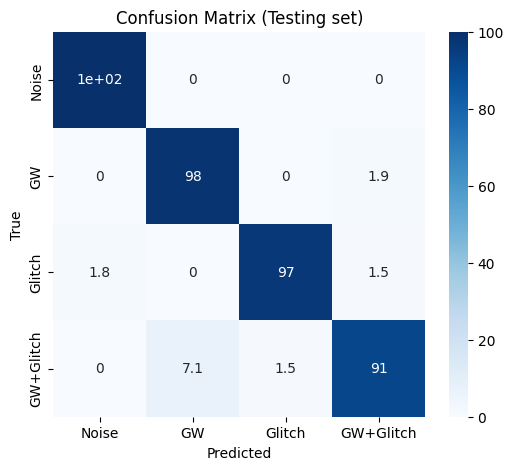

In [8]:
def label_to_class(y):
    return y[:,0]*1 + y[:,1]*2

true_class = label_to_class(labels)
pred_class = label_to_class(preds)
cm = confusion_matrix(true_class, pred_class, normalize='true')*100
np.savez(results_dir / 'confusion_matrix.npz', cm=cm)

labels_names = ["Noise", "GW", "Glitch", "GW+Glitch"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=labels_names,
            yticklabels=labels_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Testing set)")

plt.show()

In [7]:
np.where((true_class == 3)&(pred_class == 1))[0]

array([655, 656, 657, 658, 659, 661, 662, 663, 664, 725, 726, 729, 749,
       800, 801, 802, 803, 804, 835, 850, 853, 930, 931, 979])

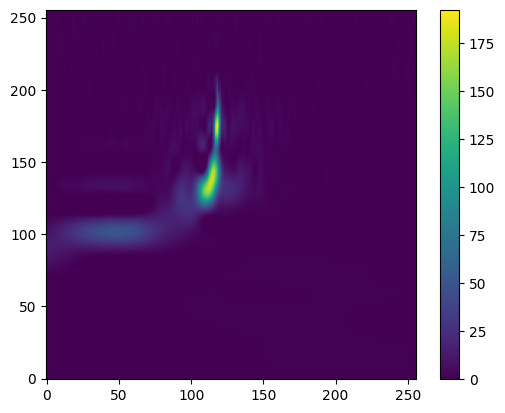

True label: tensor([1., 1.])
Sim index: 10
Time index: 2


In [10]:
image, label, sim_index, time_index = test_dataset[662]
plt.imshow(image[0], origin='lower')
plt.colorbar()
plt.show()
print('True label:', label)
print('Sim index:', sim_index)
print('Time index:', time_index)

In [8]:
wrong = np.where((true_class == 3)&(pred_class == 1))[0]
sim_indices = [test_dataset[i][2] for i in wrong]

right = np.where((true_class == 3)&(pred_class == 3))[0]
all_indices = np.array([test_dataset[i][2] for i in right])

In [16]:
all_indices

array([ 10,  15,  34,  41,  42,  49,  57,  63,  65,  69,  76, 102, 113,
       117, 137, 141, 167, 177, 182, 195, 212, 272, 275, 286, 287, 290,
       296, 300, 313, 314, 317, 333, 366, 372, 410, 432, 437, 451, 490,
       491, 500, 502, 503, 518, 526, 528, 529, 534, 535, 543, 547, 548,
       553, 555, 583, 586, 609, 617, 621, 622, 624, 643, 648, 649, 651,
       656])

In [15]:
sim_indices = np.unique(sim_indices)
all_indices = np.unique(all_indices)
with h5py.File(mixed_hm_dataset_path, 'r') as f:
    amps = f['amp'][:]
    betas = f['beta'][:]
    seps= f['sep'][:]

wrong_amps = amps[sim_indices]
wrong_betas = betas[sim_indices]
wrong_seps = seps[sim_indices]

all_amps = amps[all_indices]
all_betas = betas[all_indices]
all_seps = seps[all_indices]

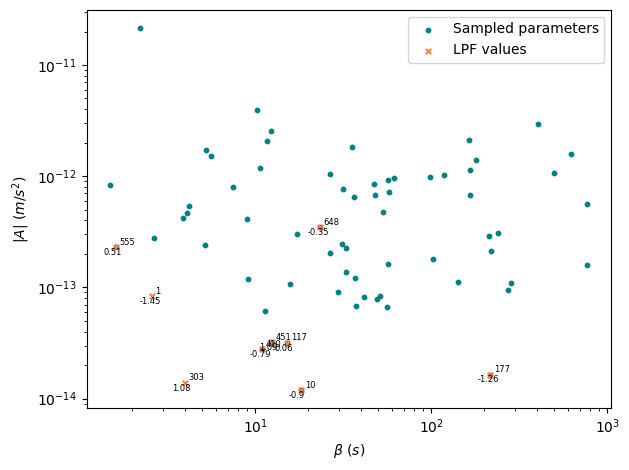

In [12]:
plt.figure(tight_layout=True)
plt.scatter(all_betas, all_amps, color='teal', s=10, label='Sampled parameters')
plt.scatter(wrong_betas, np.abs(wrong_amps), color='coral', s=15, marker='x', label='LPF values')
for i, idx in enumerate(sim_indices):
    plt.text(wrong_betas[i]*1.05, np.abs(wrong_amps[i])*1.05,
             str(idx),
             fontsize=6)
    plt.text(wrong_betas[i]*0.85, np.abs(wrong_amps[i])*0.85,
             str(round(wrong_seps[i], 2)),
             fontsize=6)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('$|A|\ (m/s^2)$')
plt.xlabel('$\\beta\ (s)$')
plt.legend()
plt.show()

In [25]:
from helpers.qtransform import generate_qscan
from helpers.simulation import make_tdi_dict

index = 34
with h5py.File(mixed_hm_dataset_path, 'r') as f:
    X = f['X'][index]
    Y = f['Y'][index]
    Z = f['Z'][index]
    #sep = f['sep'][index]
    #amp = f['amp'][index]
    #beta = f['beta'][index]

#raw_dict = {'X': X, 'Y': Y, 'Z': Z}
tdi_dict = make_tdi_dict(X, Y, Z)
event = {'t_inj': 5*3600}
tarr, farr, QT = generate_qscan(tdi_dict, 'A', PIPE, event,
                                frange=(1e-3, 1e-1), trange=(-3, 3), Q=16, resolution=256)

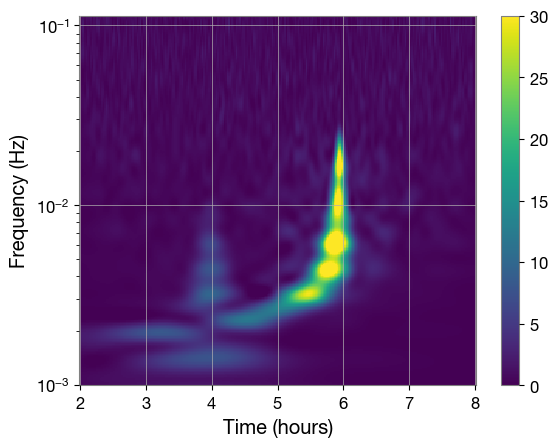

In [26]:
plt.pcolormesh(tarr/3600, farr, QT, cmap='viridis')
plt.yscale('log')
plt.clim(0, 30)
plt.xlabel('Time (hours)')
plt.ylabel('Frequency (Hz)')
plt.colorbar()
plt.show()
#print('Separation:', sep)
#print('Beta:', beta)

## Time centering

In [12]:
inference_gw_path = INFERENCE_DATASETS / 'timecen_datasets' / 'high_mass' / 'gw_timecen.h5'
with h5py.File(inference_gw_path, 'r') as f:
    all_images = f['QT'][:]
    tcen_vals = f['tcen'][:]

In [32]:
images = all_images[:, 0, :, :, :]
images = torch.tensor(images, dtype=torch.float32)
images = images.permute(0, 3, 1, 2).contiguous()

outputs = model(images.to(device))
probs = torch.sigmoid(outputs)
preds = (probs > 0.5).float()

pred_class = preds[:,0]*1 + preds[:,1]*2
pred_class = pred_class.to('cpu').numpy()

In [34]:
np.sum((pred_class == 1))/len(pred_class)

np.float64(0.9523809523809523)

In [61]:
acc = []
with torch.no_grad():
    for i in range(all_images.shape[1]):
        images = all_images[:, i, :, :, :]
        images = torch.tensor(images, dtype=torch.float32)
        images = images.permute(0, 3, 1, 2).contiguous()

        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        pred_class = preds[:,0]*1 + preds[:,1]*2
        pred_class = pred_class.to('cpu').numpy()
        acc.append(np.mean(probs.to('cpu').numpy(), axis=0))
acc = np.array(acc)

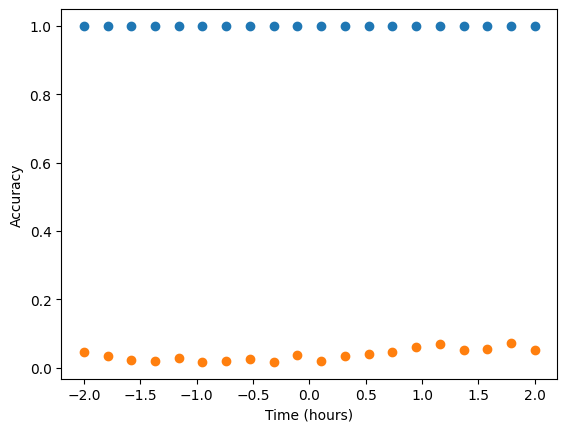

In [71]:
times = tcen_vals[0,:]

plt.scatter(times/3600, acc[:, 0])
plt.scatter(times/3600, acc[:, 1])
plt.xlabel('Time (hours)')
plt.ylabel('Accuracy')
#plt.ylim(0.95, 1.005)
plt.show()

In [81]:
SAVE_DIR = INFERENCE_DATASETS / 'timecen_datasets' / 'ext_high_mass'
results = np.load(SAVE_DIR / 'inference_results.npz')
times = results['times']
gw_acc = results['gw_acc']
glitch_acc = results['glitch_acc']

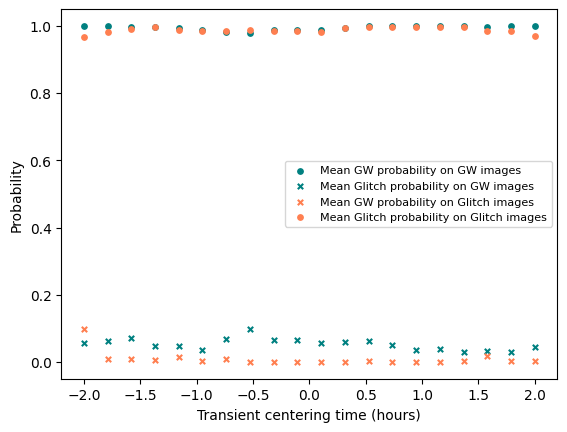

In [82]:
plt.scatter(times/3600, gw_acc[:,0], s=15, marker='o', color='teal', label='Mean GW probability on GW images')
plt.scatter(times/3600, gw_acc[:,1], s=15, marker='x', color='teal', label='Mean Glitch probability on GW images')
plt.scatter(times/3600, glitch_acc[:, 0], s=15, marker='x', color='coral', label='Mean GW probability on Glitch images')
plt.scatter(times/3600, glitch_acc[:, 1], s=15, marker='o', color='coral', label='Mean Glitch probability on Glitch images')
plt.xlabel('Transient centering time (hours)')
plt.ylabel('Probability')
plt.legend(fontsize=8)
plt.show()